# **A multi-objective optimization approach in defining the decarbonization strategy of a district heating network: The case study of Oslo**

*Master of Science Thesis in Energy Engineering at Politecnico di Milano by Yagiz Saglam*

## 1. Introduction

This study investigates the decarbonization of the Oslo district heating network by modeling its current framework using EnergyPLAN. Firstly, the research assesses the system’s current annual CO₂ emission and total annual costs to be considered as baseline scenario, then examines possible enhancements in decarbonization and cost reduction through a Multi-Objective Evolutionary Algorithm (MOEA) NSGA-II combined with EnergyPLAN. This notebook documents the multi-objective optimization analysis conducted for the mentioned study.

## 2. Problem Formulation


- **Objectives**: Minimize CO₂ emissions & total annual costs
- **Decision variables**:
  1. Waste-to-energy plant capacity (fuel input)
  2. Waste heat (industrial excess heat) import capacity
  3. Biomass boiler thermal capacity
  4. Natural gas boiler thermal capacity
  5. Oil boiler thermal capacity
  6. Heat pump electric capacity
  7. Electric boiler electric capacity
  8. Thermal energy storage capacity
  9. Carbon capture and storage (CCS) capacity
- **Constraints**: There is no contraint in this study.

## 3. MOEA Implementation with NSGA-II in Python for the Case Study of Oslo

In this section, the multi-objective optimization approach based on the NSGA-II algorithm is implemented in Python to explore trade-offs between minimizing CO₂ emissions and total annual cost in district heating network decarbonization scenarios. The code is presented with detailed line-by-line explanations to ensure transparency and understanding of the modeling process.

In [1]:
import inspect
from IPython.display import display, Markdown

from moea.models import get_model

model_name = "Oslo"
model = get_model(model_name)

# Print models class __init__ code
init_code = inspect.getsource(model.__init__)
display(Markdown("```python\n" + init_code + "```"))

evaluate_code = inspect.getsource(model._evaluate)
display(Markdown("```python\n" + evaluate_code + "```"))

2025-08-28 11:59:26.135 | INFO     | moea.config:<module>:11 - PROJ_ROOT path is: C:\Users\Urbani\moea


```python
    def __init__(self,
                 data_file: Union[str, Path] = "Oslo_2objectives_baseline.txt",
                 **kwargs):
        """
        Parameters:
        -----------
        - ``data_file``: str or Path

            The path to the input file. This file is used as a template to
            generate the input files for each individual.

            The values will be replaced by the values of the decision variables
            when generating the input files.
        """
        # Definition of decision variables, with their power and upper bounds
        """
        The mentioned decision variables in problem definition section are listed
        here. To modify these decision variables on EnergyPLAN, their unique naming
        on the software input text file are found. For example, to modify the
        waste-to-energy plant fuel input value under the group 2, the correct
        variable name used in EnergyPLAN is "input_Waste2_Waste".

        The definition of the district heating boiler capacity under supply section
        of EnergyPLAN is done by the following variable: "input_cap_boiler2_th".
        To define the fuel shares (among natural gas, oil and biomass) of this
        total capacity, the following variables are used, respectively:

        ```
        input_fuel_Boiler2[2]
        input_fuel_Boiler2[3]
        input_fuel_Boiler2[4]
        ```

        Since the boiler is a peak supply technology, the total capacity of the
        boiler is not defined as a decision variable here. To be sure that this
        peak demand is satisfied by the boilers, the random values are assigned
        for other technologies first, with a high boiler capacity, and the software
        is executed. Then, the results are obtained for all individuals and the
        boiler maximum power is read and replaced with the high capacity defined
        in the beginning. This approach guarantees the satisfaction of the demand
        considering the need boiler cpacity only.

        The lower and upper bound values are calculated considering some physical
        constarints of the case study.

        The last clarification of the decision variable list is about heat pump
        and electric boiler definitions in this optimization. The EnergyPLAN kicks
        the electric boiler in the production when there is excess of electricity
        in the system. Since there is no electricity modelling in this case study,
        i.e. district heating only modelling, the electric boiler usage is done by
        defining the heat pump COP value as 1. For the heat pump utulization, the
        COP value is defined as 3.39. Therefore, COP value of heat pump 2 definition
        is taken here as a decision variable with its electric capacity. The cost
        of these two technologies are defined in the baseline file as zero, but the
        post-processing is done for the total annual cost correction before proceeding
        with the next generation.

        """
        self.vars = pd.DataFrame.from_dict({
            'input_Waste2_Waste': {"lb": 1.361, "ub": 2.722},
            'input_ind_surplus_heat2': {"lb": 0, "ub": 0.379},
            'input_fuel_Boiler2[2]': {"lb": 0, "ub": 1},
            'input_fuel_Boiler2[3]': {"lb": 0, "ub": 1},
            'input_fuel_Boiler2[4]': {"lb": 0, "ub": 1},
            'input_eff_hp2_cop': {"lb": 1, "ub": 3.39},
            'input_cap_hp2_el': {"lb": 0, "ub": 681},
            'input_storage_gr2_cap': {"lb": 0, "ub": 100},
            'input_CO2_CCS': {"lb": 0, "ub": 0.278},
        }, dtype=float, orient='index')

        # Initialize the parent class
        super().__init__(
            n_var=len(self.vars),
            n_ieq_constr=0,
            n_obj=2,
            xl=self.vars['lb'].values,
            xu=self.vars['ub'].values,
            data_file=data_file,
            **kwargs
        )
        # This part is added to store the decision variable values and
        # needed outputs of each individual in each generation in a cvs file.

        self.generation = 0  # Add generation counter

        # Define CSV file path
        self.csv_file = "oslo_results.csv"

        # If CSV doesn't exist, initialize it with headers
        if not os.path.exists(self.csv_file):
            with open(self.csv_file, "w") as f:
                headers = ["Generation", "Individual"] + \
                          [f"X{i}" for i in range(self.n_var)] + \
                          ["CO2_Emissions", "Total_Cost","El_Import",
                           "Boiler2_Heat","HP2_Heat","Storage2_Heat",
                           "Balance2_Heat", "Boiler_Capacity"]
                f.write(",".join(headers) + "\n")
```

```python
    def _evaluate(self, x, out, *args, **kwargs):

        # Start with default peak boiler capacity at beginning of every generation
        self.fixed_boiler_capacity = 681

        decision_vars = [
            {k: ind[j] for j, k in enumerate(self.vars.index)} for ind in x
        ]

        processed_vars = [self.preprocess_variables(i) for i in decision_vars]

        # Add the fixed boiler capacity into processed variables
        for vars in processed_vars:
            vars["input_cap_boiler2_th"] = self.fixed_boiler_capacity

        # Call EnergyPLAN using spool mode
        self.energyplan.run(inputs=processed_vars)

        # Retrieve values for boiler heat
        actual_boiler_capacity = self.energyplan.read_values(
            ("Annual Maximum", "Boiler 2 Heat")
        ).ravel()

        # Add the fixed boiler capacity into processed variables
        for i, vars in enumerate(processed_vars):
            vars["input_cap_boiler2_th"] = actual_boiler_capacity[i]

        # Parse the output file
        Y = self.energyplan.read_values(
            "CO2-emission (corrected)",
            "TOTAL ANNUAL COSTS",
            "Oil Consumption",
            "Ngas Consumption",
            ("Annual", "Import Electr."),
            ("Annual", "Boiler 2 Heat"),
            ("Annual", "HP 2 Heat"),
            ("Annual", "Storage2 Heat"),
            ("Annual", "Balance2 Heat"),
            ("Annual Maximum", "Boiler 2 Heat"),
        )

        """
        After executing the EnergyPLAN twice, the first with a high boiler
        capacity, the second with the needed boiler capacity, some output data
        are collected and stored. These outputs can be read depending on the
        case study and post processing need. The post-processing of total CO2
        emission and the total annual cost are done for the following
        corrections in this case study:
        For the total annual cost:
            1. Annual cost of heat pump
            2. Annual cost of electric boiler
            3. Annual cost of CCS unit
            4. Cost of industrial excess heat
            5. Carbon pricing (fossil carbon emission price is different than
            waste burning carbon emission price)
            6. Revenue of electricty production by waste-to-energy plant
        For the total CO2 emissions:
            1. Electricty import (additional emissions according to national
            grid emission factor)
        """
        oil_consumption = Y[:, 2]
        ng_consumption = Y[:, 3]
        electricity_import = Y[:, 4]
        waste_input = x[:, 0]
        industrial_excess_heat = x[:, 1]
        COP = x[:, 5]
        HP_EB_capacity = x[:, 6]
        CCS_capacity = x[:, 8]

        HP_share = (COP - 1) / (3.39 - 1)
        HP_el_capacity = HP_EB_capacity * HP_share
        EB_el_capacity = HP_EB_capacity - HP_el_capacity
        EB_th_capacity = EB_el_capacity * 0.99

        cost_HP = (HP_el_capacity * 2.328 * 0.036) / (1 - (1 + 0.036)**-25) \
            + HP_el_capacity * 2.328 * 0.0031
        cost_EB = (EB_th_capacity * 0.138 * 0.036) / (1 - (1 + 0.036)**-20) \
            + EB_th_capacity * 0.138 * 0.0036
        cost_CCS = (CCS_capacity * 2077 * 0.036) / (1 - (1 + 0.036)**-25) \
            + CCS_capacity * 2077 * 0.03614
        cost_co2 = (
            oil_consumption * 74000 * 3.6 / 10**6 + \
                ng_consumption * 56700 * 3.6 / 10**6) * 77 + \
                    waste_input * 56890 * 3.6 / 10**6 * 20.84
        cost_industrial_excess_heat = industrial_excess_heat * 29
        revenue_WtE = waste_input * 0.1117 * 67

        cost_add = cost_HP + cost_EB + cost_CCS + cost_co2 + \
            cost_industrial_excess_heat - revenue_WtE

        co2_el_import = electricity_import * 0.0106

        co2_add = co2_el_import

        # Update objective values
        out["F"] = np.column_stack([Y[:, 0] + co2_add, Y[:, 1] + cost_add])


        # Save results to CSV
        df = pd.DataFrame({
            "Generation": self.generation,
            "Individual": np.arange(len(out["F"])),
        })

        for i in range(x.shape[1]):
            df[f"X{i}"] = x[:, i]

        df["CO2_Emissions"] = out["F"][:, 0]
        df["Total_Cost"] = out["F"][:, 1]
        df["El_Import"] = Y[:, 4]
        df["Boiler2_Heat"] = Y[:, 5]
        df["HP2_Heat"] = Y[:, 6]
        df["Storage2_Heat"] = Y[:, 7]
        df["Balance2_Heat"] = Y[:, 8]
        df["Boiler_Capacity"] = Y[:, 9]

        # Append data to the CSV file
        df.to_csv(self.csv_file, mode="a", header=False, index=False)

        # Increment generation counter for next call
        self.generation += 1
```

## 4. Results

According to the baseline scenario calculations, this district heating system can be operated with 148.17 M€ annual total cost and annual 0.294 MtCO₂ emission value. The results presented here are categorized into four main groups, based on different optimization scenarios. The categories correspond to the following changes applied in each case:

1. Assigning the maximum calculated values as the upper limits
2. Setting the heat pump capacity to zero
3. Setting both the heat pump and electric boiler capacities to zero
4. Setting the heat pump and electric boiler capacities, as well as the biomass share, to zero.

### 4.1. No limit optimization results

In the first step of the optimization (no-limit scenario), a MOEA with 100 individuals over 50 generations was run. The final solutions from generation 50 formed a clear Pareto front, indicating full convergence with all solutions being non-dominated. A notable slope change in the Pareto front reflects a shift toward CCS technologies.

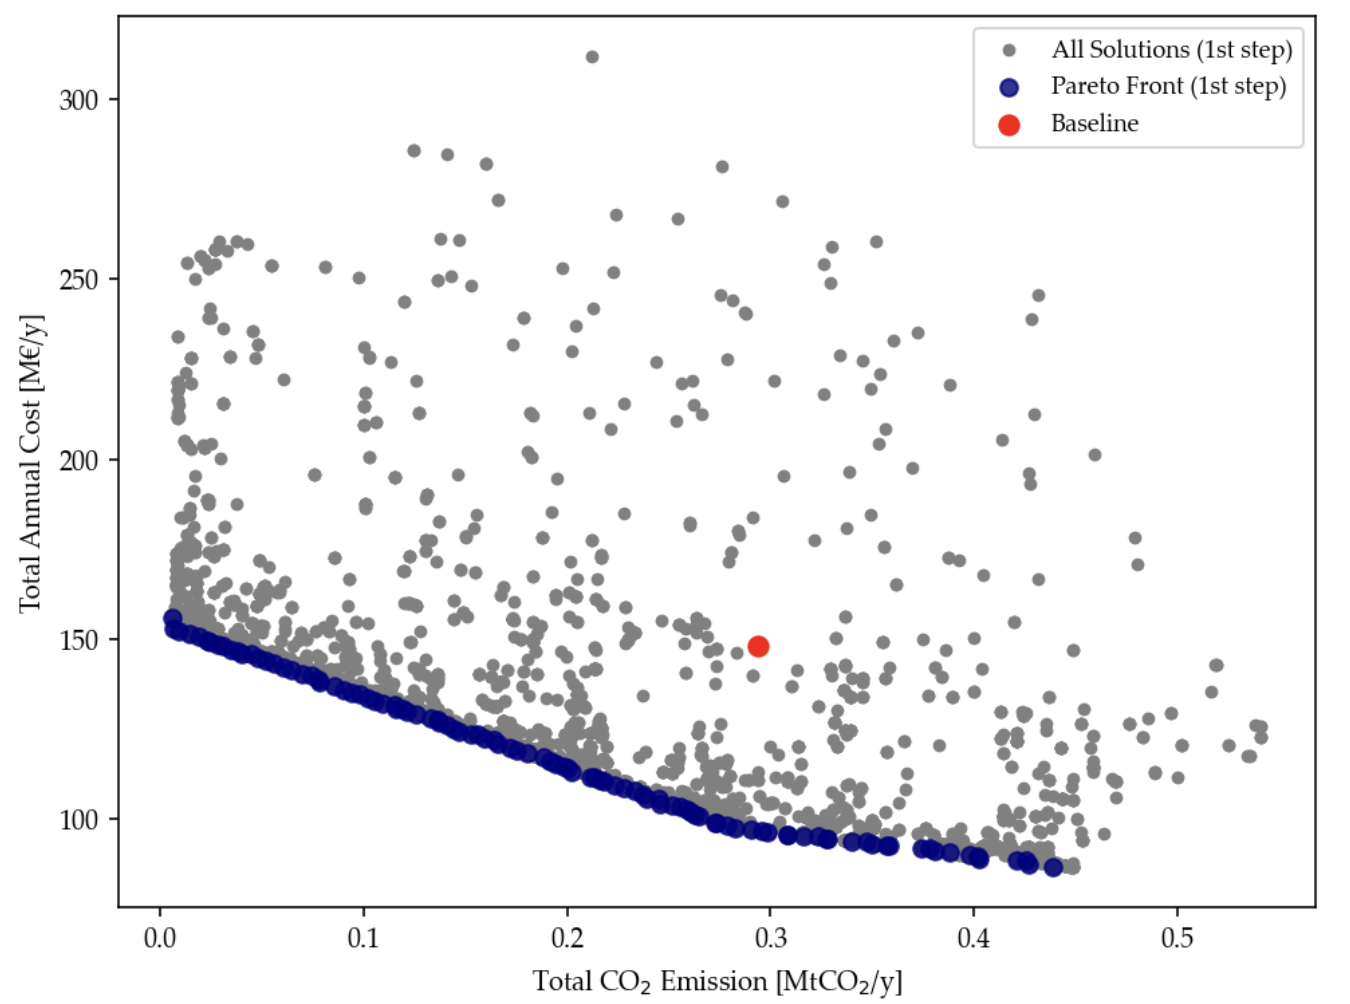

From generation 20 onward, the algorithm consistently produced 100 non-dominated solutions, signaling optimization stability. This progression demonstrates how the algorithm refines its search, gradually improving the quality of the non-dominated solutions and leading to an optimized
Pareto front over generations.

This is further confirmed by the hypervolume analysis, which showed a steady increase followed by a plateau, indicating convergence.

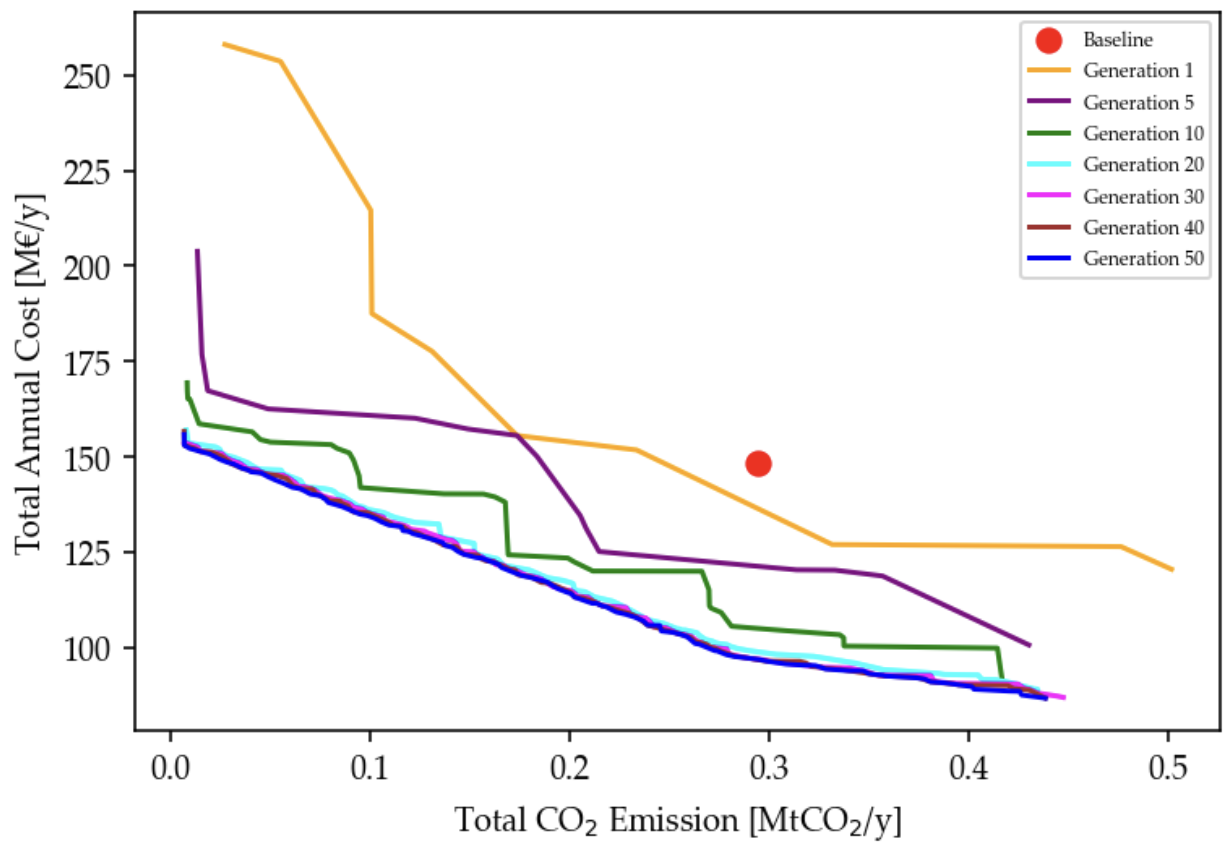

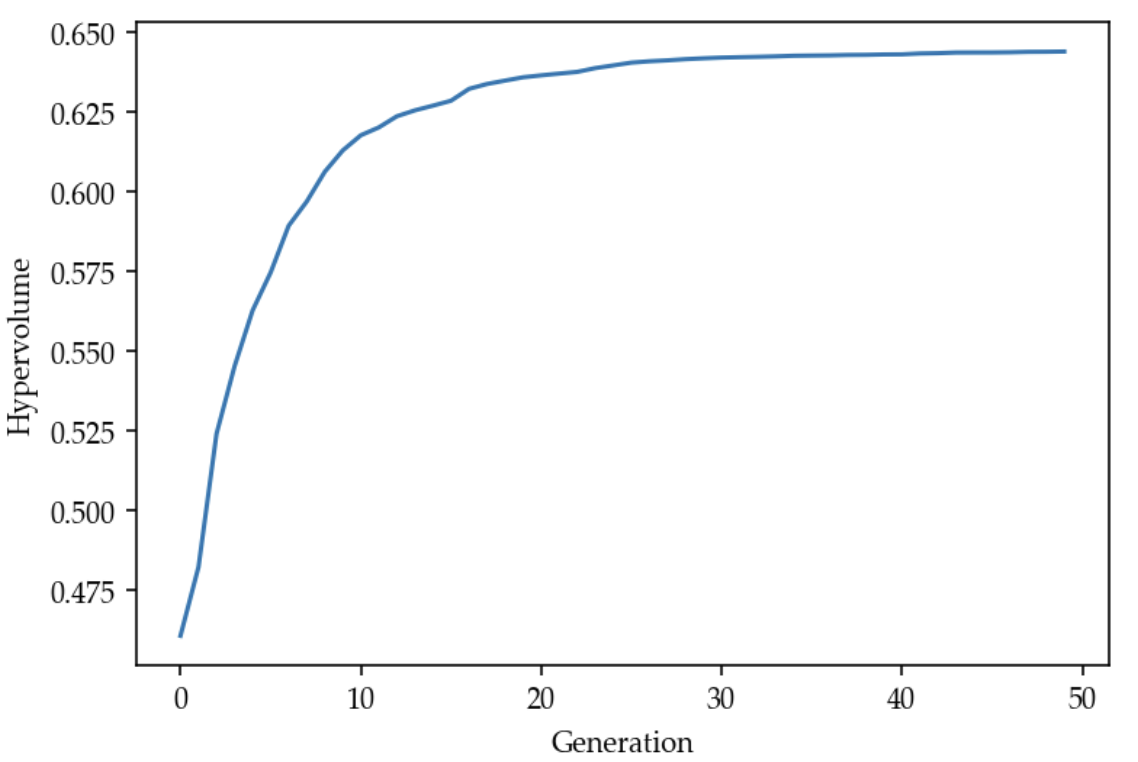

At this stage, the focus is on analyzing the annual heat production values and their technological breakdown. Each individual in the optimization was simulated in EnergyPLAN to ensure heat demand was met, yielding both decision variables and heat production outputs. Using the final Pareto front from generation 50, the following figure shows total CO₂ emissions alongside the technological composition of heat production (primary axis) and installed CCS capacity (secondary axis).

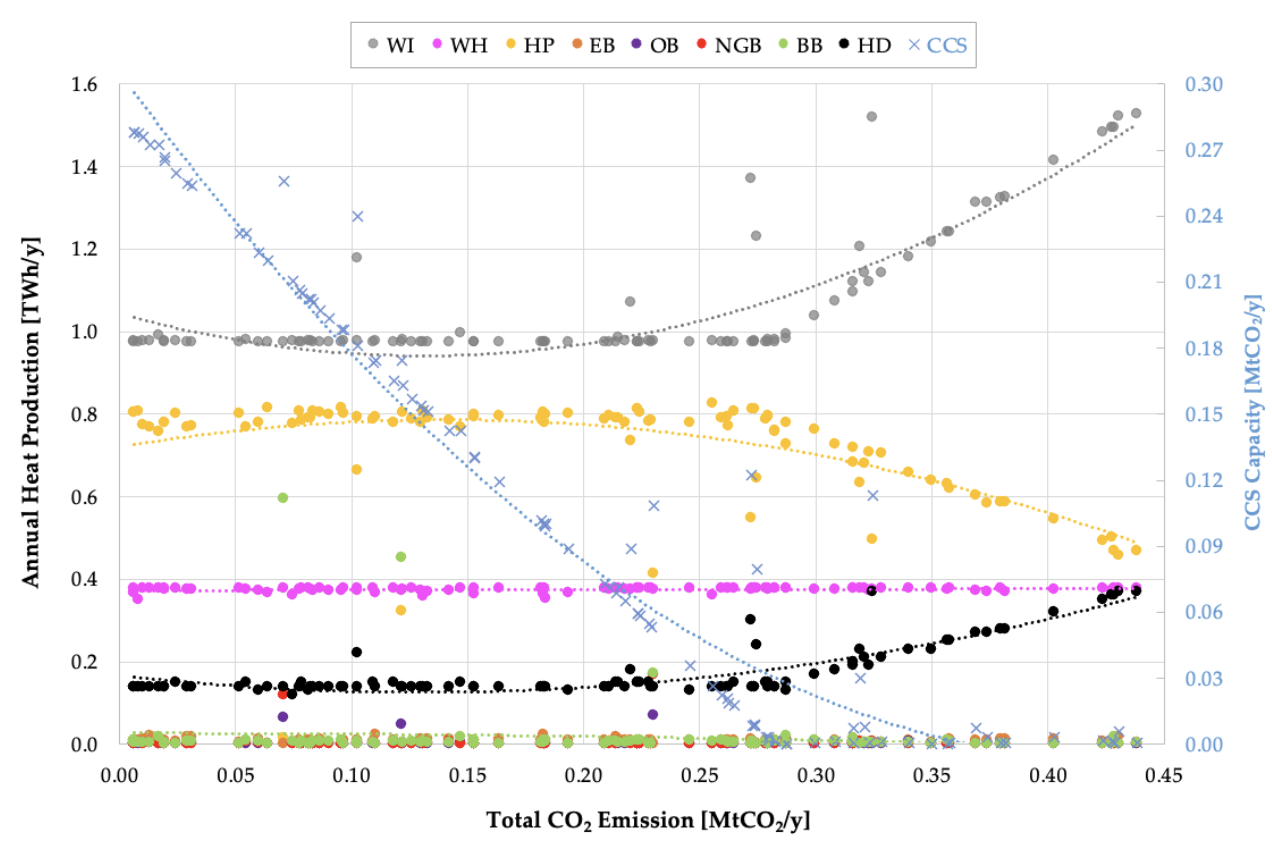

The analysis of annual heat production highlights three key technologies: the WtE plant, heat pumps, and industrial waste heat. The WtE plant consistently operates at or above its minimum capacity to avoid exclusion in decarbonisation efforts, which keeps emissions near baseline levels without CCS. When WtE capacity is expanded, reliance on heat pumps for peak demand decreases, but off-peak production increases, causing more heat dissipation. Despite this, Thermal Energy Storage (TES) remains unused due to high capital costs, as shown by near-zero values in the data and its exclusion from the graph.

A total of 77 decarbonization solutions were identified, 64 of which achieve both lower emissions and reduced annual costs compared to the baseline scenario. Across all cases, heat pumps—despite their higher investment cost—are consistently preferred over electric boilers due to their superior efficiency, delivering 3.39 times more thermal energy per unit of electricity. This leads to lower annual costs. In scenarios with the lowest emissions, the integration of CCS increases total costs, causing the observed slope change in the Pareto front.

A striking aspect of this technological distribution is that, aside from heat pump and waste heat, almost no other technology contributes significantly to total heat production. Therefore, it seems logical to proceed with the second stage of optimization to analyze which technologies would emerge if the heat pumps were eliminated from the system.

### 4.2. Heat pump eliminated optimization results

In this optimization step, the COP of the heat pump definition in EnergyPLAN was capped at 1, effectively removing it and favoring electric boiler operation in decarbonization scenarios. To enable comparison, the new Pareto front is overlaid on that of step 1. As expected, removing the heat pump led to a diagonal shift in the Pareto front, indicating higher total annual costs and CO₂ emissions. Fast convergence was again observed, as reflected in the similar hypervolume evolution graph of step 1.



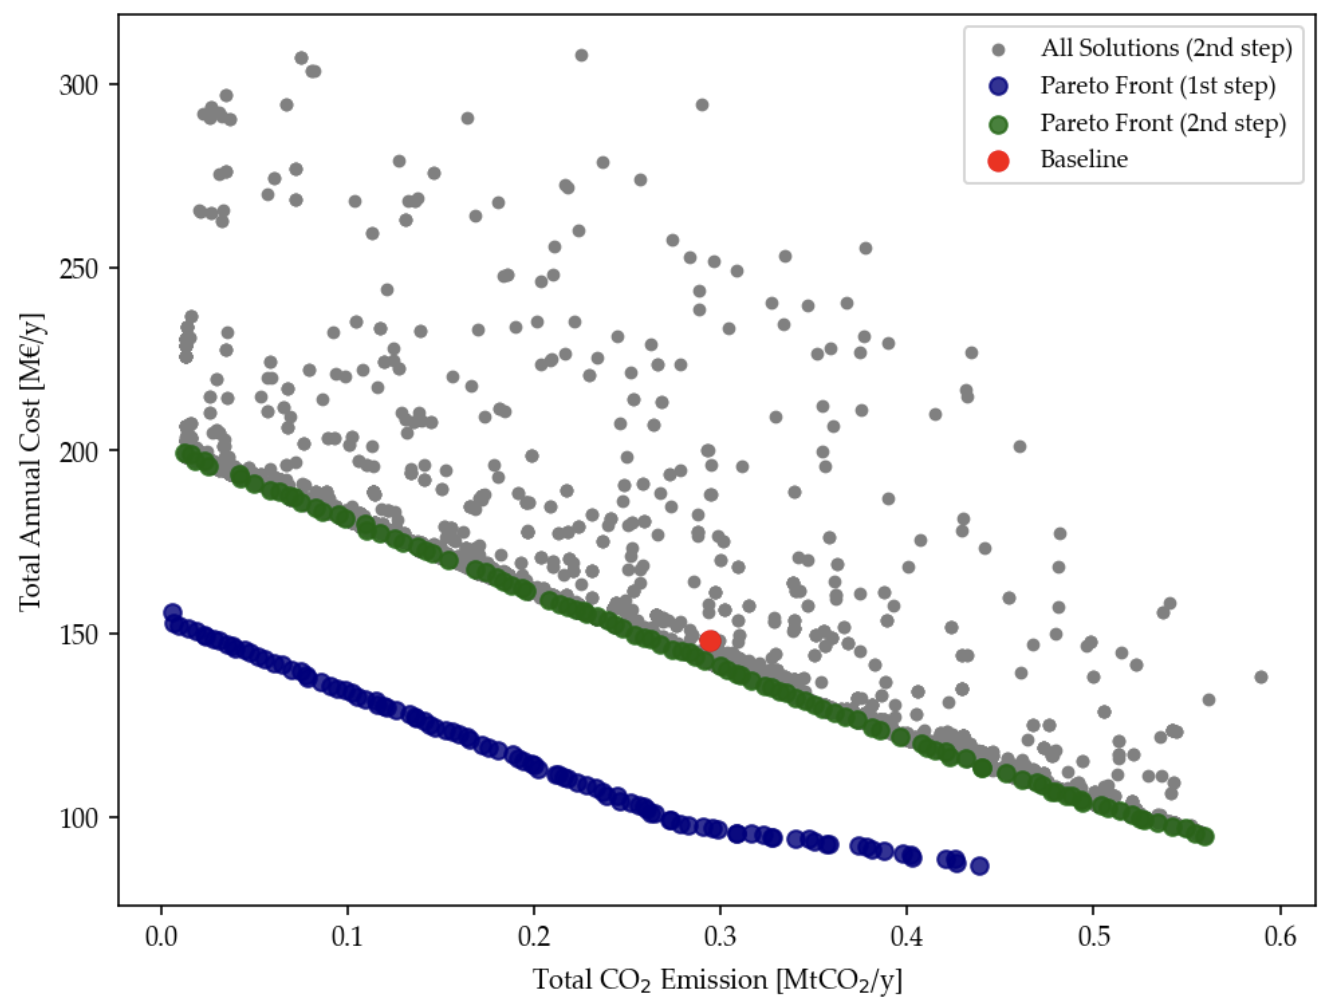

Using these outputs obtained from 100 non-dominated solutions in the last generation, the following graph illustrates total CO₂ emissions along with the technological breakdown of total heat production and the installed CCS capacity on the secondary axis.

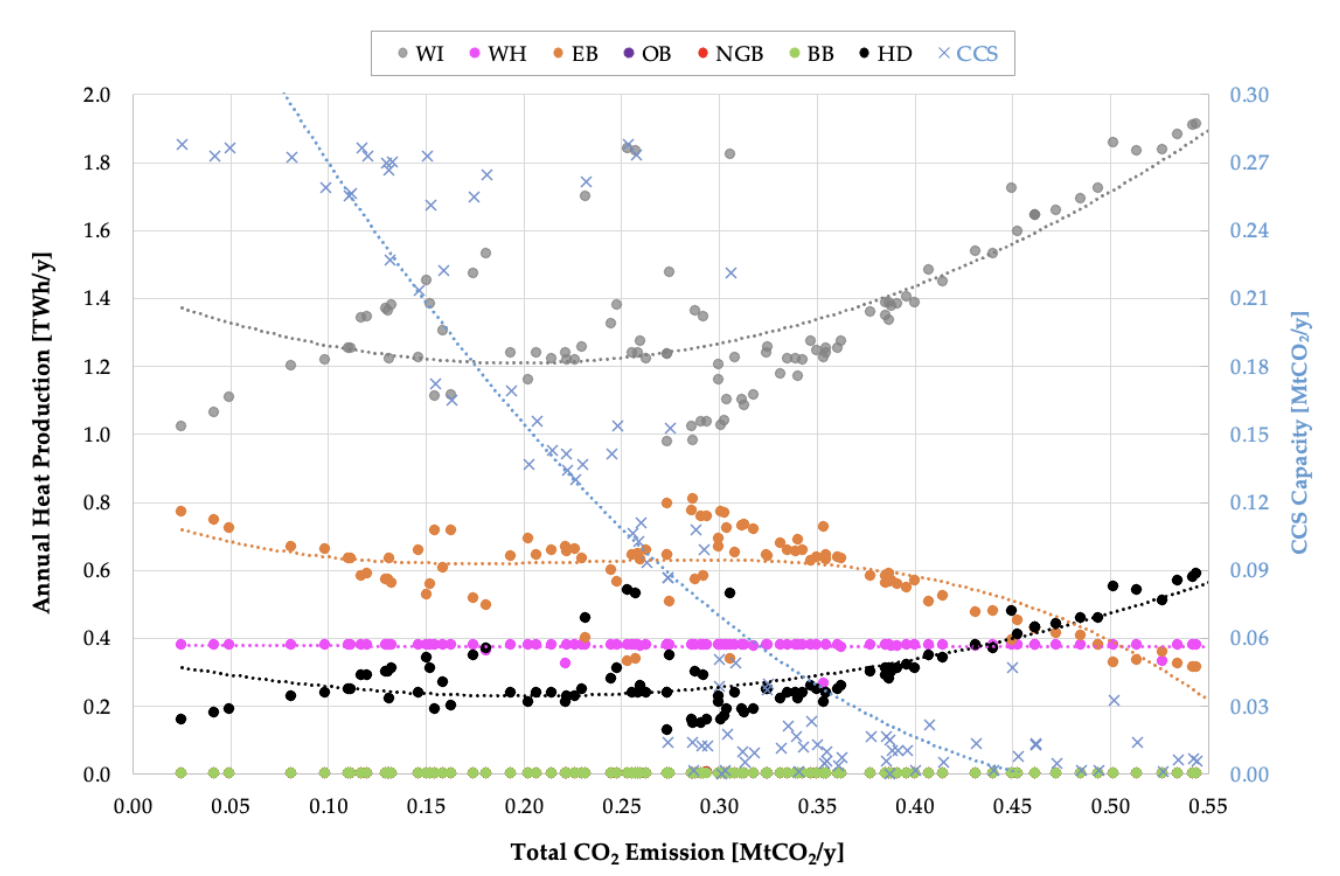

Compared to the first optimization step, the main change in this stage is the increased use of electric boilers, which replaced heat pumps after their removal. Although biomass could have been an alternative, its high fuel costs—especially since much of it is biodiesel, not just wood—made it less competitive than electric boilers. Waste heat remained fully utilized, as in the first step.

This stage produced 58 solutions with lower CO₂ emissions than the current level, 9 of which also achieved a slight reduction in total annual cost. In these cost-effective solutions, waste heat was maximized, the WtE plant maintained or exceeded baseline operation, electric boilers met the remaining demand, and CCS was used to achieve deep decarbonization. Notably, the system demonstrated that decarbonization with cost savings is possible even without heat pumps, despite the inclusion of high-cost CCS technology.

### 4.3. Electrification eliminated optimization results

In this optimization step, both the heat pump and electric boiler were removed to assess decarbonization without electrification. The EnergyPLAN simulations were run with 100 individuals over 50 generations. The resulting Pareto front again exhibits a diagonal shift, indicating higher costs are required to achieve the same level of CO₂ emissions compared to previous steps.

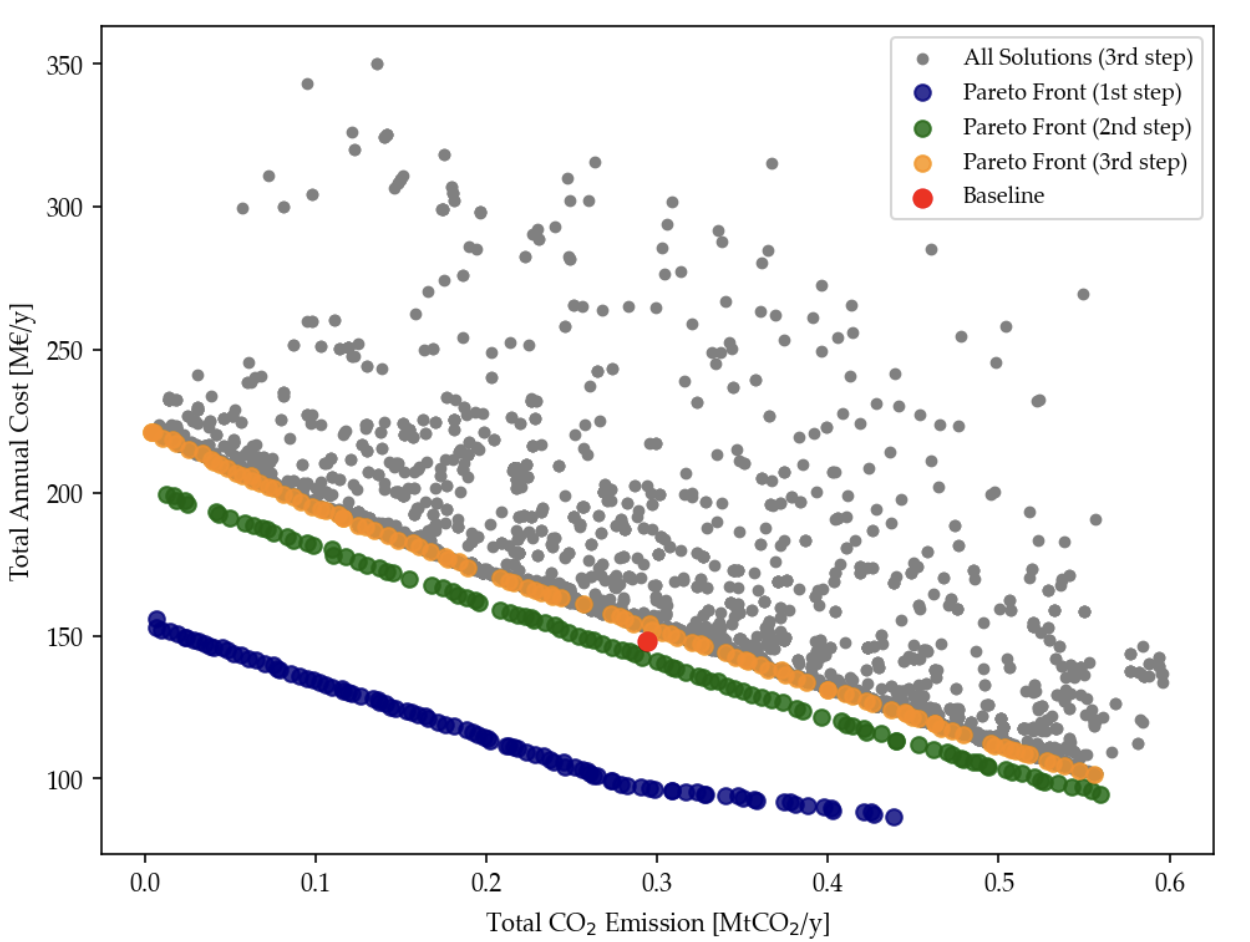

In this step, with electrification removed, waste heat remains fully utilized, and the remaining heat demand is covered by biomass boilers. CO₂ emissions can still be reduced through the adoption of CCS. Increasing WtE plant capacity allows the system to operate at higher emissions but with lower costs, as seen in earlier steps. Out of 100 non-dominated solutions, 57 achieve decarbonization. However, none of these solutions reduce total annual costs below the current level. The lowest-cost scenario shows similar emissions with about a 5% cost increase. Among decarbonization options in the 150–170 M€ range, the most cost-effective involve CCS integration, high WtE capacity, and biomass boilers.

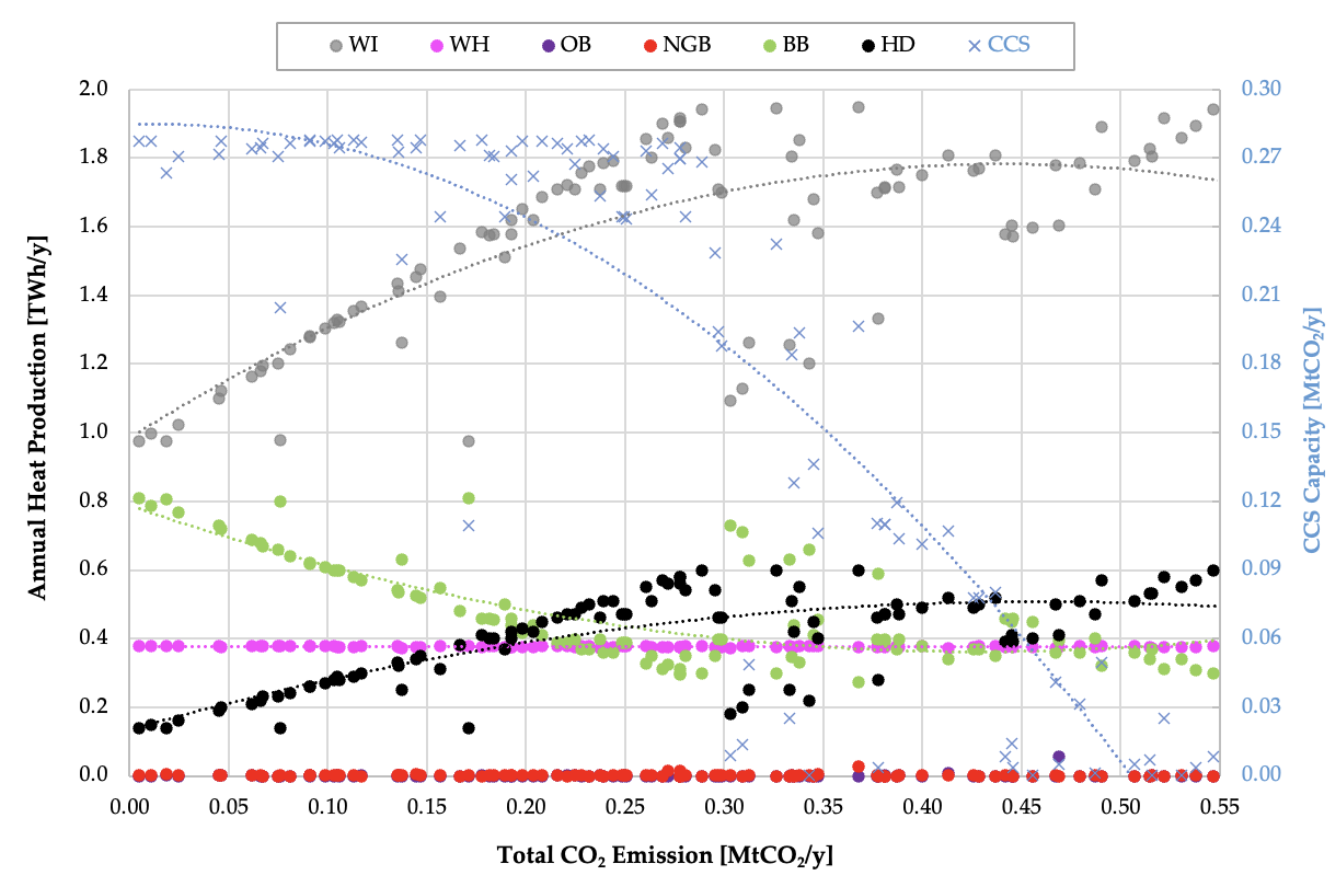

### 4.4. Carbon capture and storage only optimization results

In the final optimization step, heat pumps, electric boilers, and biomass boilers were all removed to assess decarbonization potential without these key technologies. Using the same simulation setup, the resulting Pareto front shows a diagonal shift, indicating that the cost of decarbonization increases more sharply. Unlike the previous three steps, zero emissions are not achievable in this configuration.



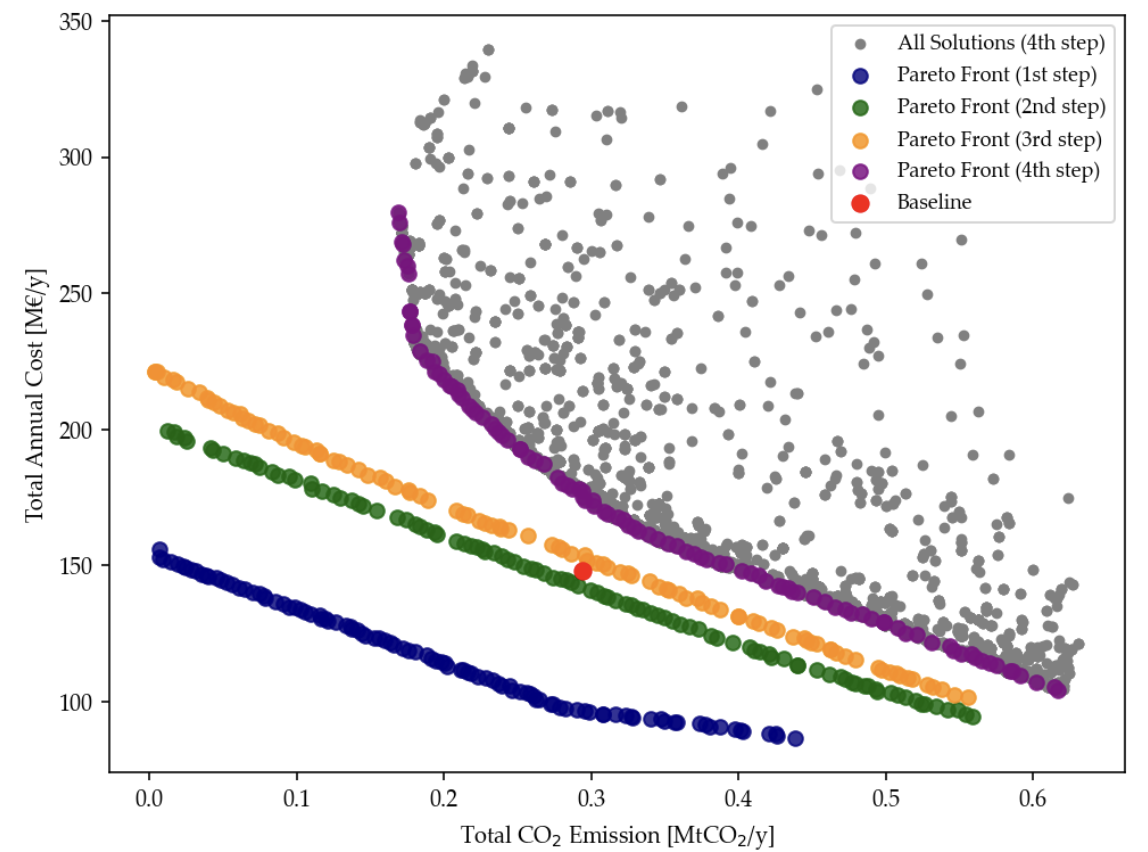

Since CCS capacity was limited to offset emissions only from the WtE plant, achieving zero CO₂ emissions was not possible in this step. The system relies on high-emission natural gas boilers to meet the remaining heat demand, leading to incomplete decarbonization. In the 100 non-dominated solutions, 43 achieve lower emissions, all by utilizing CCS at maximum capacity. However, even the lowest-cost decarbonization solution is about 20% more expensive than the current annual cost, highlighting the lack of alternative low-emission technologies in this configuration.

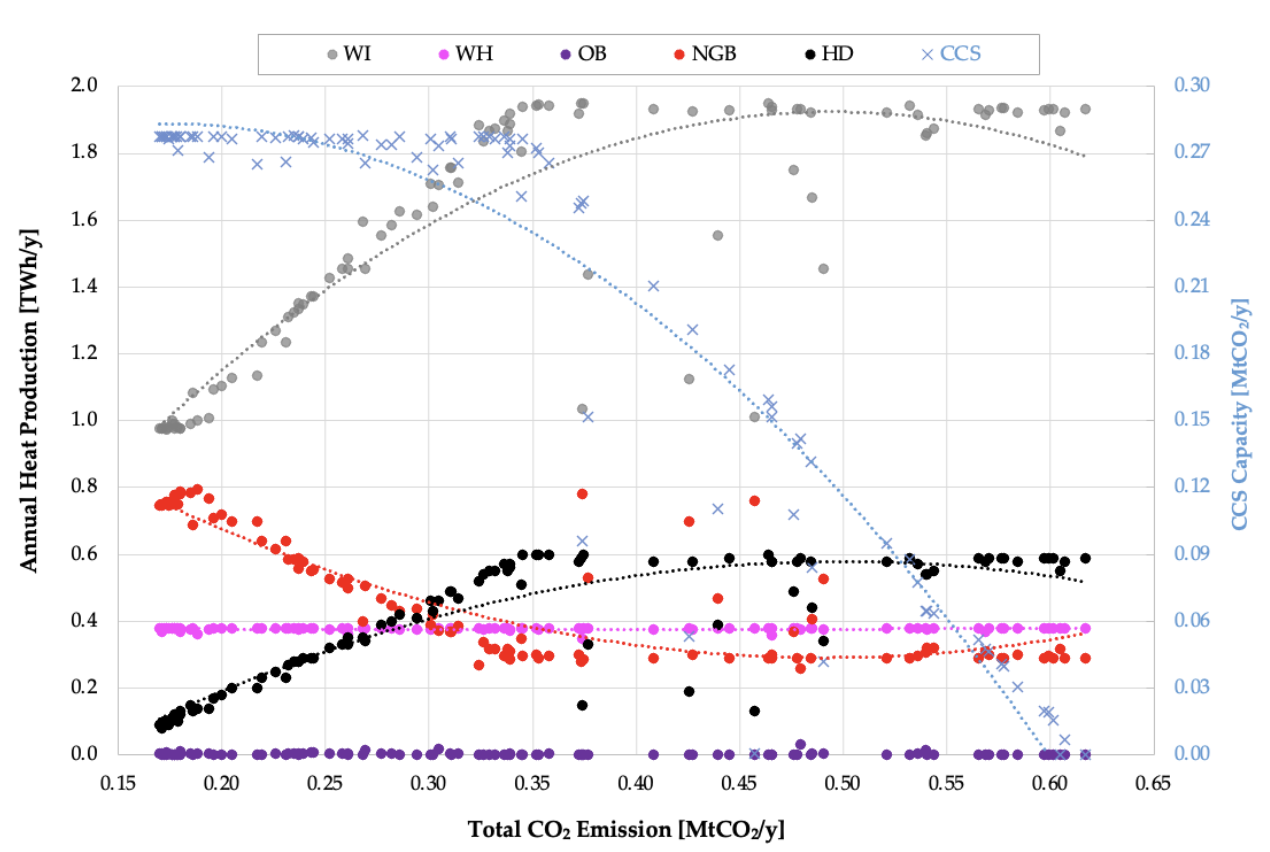

## 5. Conclusion

The MOEA optimization study conducted on the Oslo district heating
network through four different steps demonstrated that the decarbonization of the current system can be achieved using a single technology. If this technology is a heat pump, several low-cost scenarios can also be identified. However, this does not imply that the system should rely solely on a single fuel source or technology for its operation. By considering various technical and regional constraints, a combination of multiple technologies can ensure the system's continuity while also enabling cost- effective decarbonization solutions.

***The results, figures, and interpretations presented in this notebook are part of ongoing academic research and are protected by copyright. They are intended solely for internal academic purposes and are not authorized for public sharing, distribution, or reproduction without explicit written permission from the author and the affiliated institution. Unauthorized use or dissemination of this content is strictly prohibited.***